# VSLICE VLM Graph Data Analysis Pipeline
This notebook contains the graph evaluation, error analysis, and visualization pipeline for video highlight detection and calibration.

In [1]:
import os
import json
import torch
import torch.nn as nn
from torch_geometric.nn import GATConv
import h5py
import numpy as np
import random
import networkx as nx
from tqdm import tqdm
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.metrics.pairwise import rbf_kernel
import matplotlib.patches as mpatches
import matplotlib.pyplot as plt
import torch.nn.functional as F
import copy
from vslice_utils.helpers import set_seed, compute_video_metrics
import pandas as pd
from vslice_utils.dataloader import build_summe_manifest, build_tvsum_manifest, VideoSegmentDataset

In [2]:
class Args:
    model_type = "minicpm"
    dataset = "summe"
    root_dir = "../"
    output_dir = "../vslice_features/"
    model_path = None
    split_file = "../dataset/summe_splits.json"

# Initialize and Run
args = Args()

manifest = []
if args.dataset in ("summe", "both"):
    manifest.extend(build_summe_manifest(args.root_dir))
    dataset_name = "summe"

if args.dataset in ("tvsum", "both"):
    manifest.extend(build_tvsum_manifest(args.root_dir))
    dataset_name = "tvsum"

summe_h5 = os.path.join(args.root_dir, "SumMe", "eccv16_dataset_summe_google_pool5.h5")
tvsum_h5 = os.path.join(args.root_dir, "TVSum", "eccv16_dataset_tvsum_google_pool5.h5")

h5_data = h5py.File(summe_h5, 'r')

splits = []
if args.split_file and os.path.exists(args.split_file):
    with open(args.split_file, 'r') as f:
        splits = json.load(f)
    print(f"Loaded {len(splits)} splits from {args.split_file}")

[DATA] SumMe: 25 videos discovered
Loaded 5 splits from ../dataset/summe_splits.json


In [3]:
def build_adjacency_matrix_pytorch(features, picks, window_size=15, threshold=0.95, device="cpu"):
    if features.dim() == 3:
        features = features.squeeze(1)
    num_picks = features.size(0)
    
    # Cosine similarity
    norms = torch.linalg.norm(features, dim=1, keepdim=True)
    norm_features = features / (norms + 1e-8)
    sim_matrix = torch.matmul(norm_features, norm_features.t())
    threshold = torch.quantile(sim_matrix, threshold)
    
    # Create an index array [0, 1, 2... N] instead of raw frame numbers
    idx = torch.arange(num_picks, device=device)
    diff_idx = torch.abs(idx.unsqueeze(1) - idx.unsqueeze(0))
    
    # Mask 1: Within window size (e.g., up to 15 nodes away)
    temporal_mask = (diff_idx >= 1) & (diff_idx <= window_size)
    
    # Mask 2: Only keep strong visual similarities
    similarity_mask = sim_matrix >= threshold
    
    # Combine masks
    valid_connections = temporal_mask & similarity_mask
    
    backbone_mask = (diff_idx == 1)
    
    W_base = torch.zeros((num_picks, num_picks), dtype=features.dtype, device=device)
    W_base[valid_connections] = sim_matrix[valid_connections]
    
    return W_base, backbone_mask

car_over_camera
Graph constructed successfully!
Total Nodes: 293
Total Edges: 2187 (292 backbone + 1895 similarity connections)


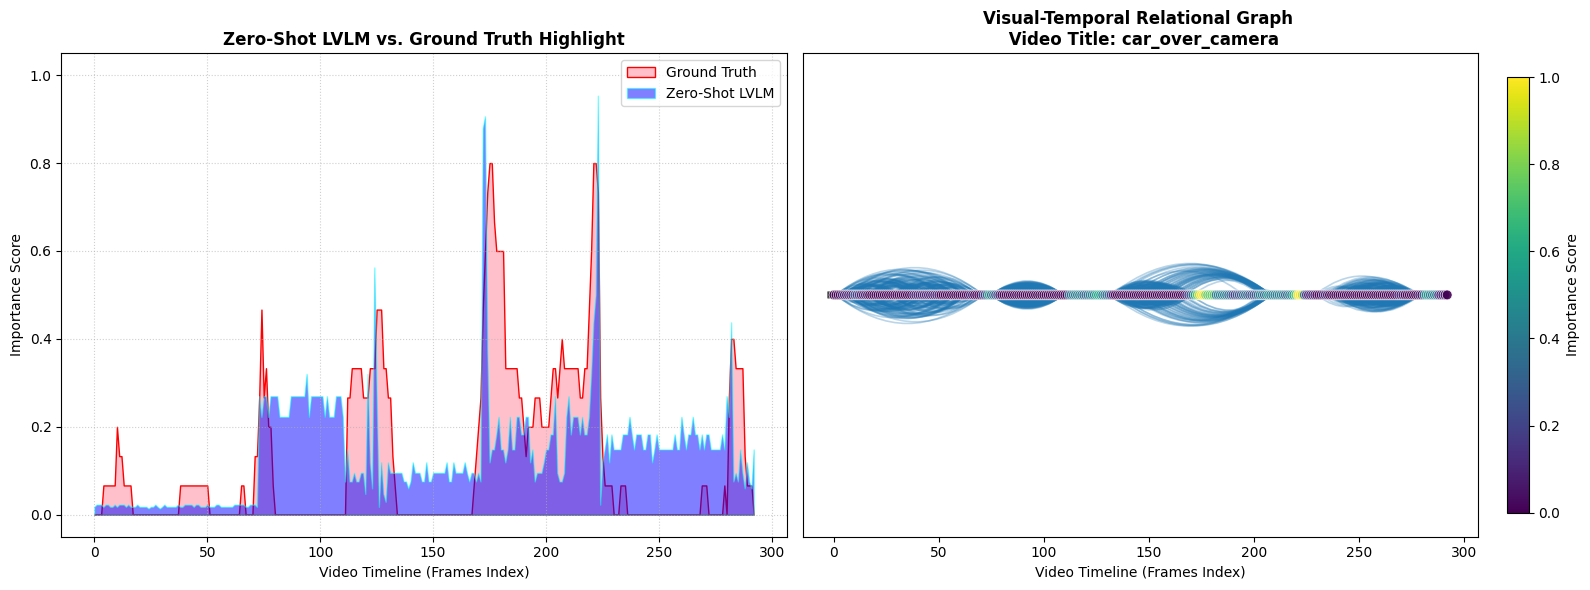

In [5]:
video_name = "video_23"
features = np.array(h5_data[video_name + '/features']) # this is features from the h5
picks = np.array(h5_data[video_name + '/picks'])
gtscore = np.array(h5_data[video_name + '/gtscore'])

video_filename = str(np.array(h5_data[video_name + '/video_name']))
video_filename = video_filename.strip("b'").strip('"').strip()
print(video_filename)

file_path = f'../vslice_features/{args.model_type}/summe_features_{video_filename}.npz' #this is features from the VLM 
data = np.load(file_path)

vlm_scores = data['p_yes']

### BUILD GRAPH ###
feat_tensor = torch.from_numpy(features).float()
picks_tensor = torch.from_numpy(picks)

W_base_tensor, backbone_mask = build_adjacency_matrix_pytorch(
    feat_tensor, picks_tensor, window_size=200)
W_base_np = W_base_tensor.cpu().numpy()

G_temporal = nx.DiGraph()
num_nodes = len(picks)

for i in range(num_nodes):
    G_temporal.add_node(i, score=float(gtscore[i]))

backbone_edges = []
for i in range(num_nodes - 1):
    G_temporal.add_edge(i, i + 1, edge_type='backbone')
    backbone_edges.append((i, i + 1))

rows, cols = np.where(W_base_np > 0)
similarity_edges = []

for r, c in zip(rows, cols):
    if r < c:  # Avoid duplicate undirected pairs
        if abs(r - c) > 1:  # Long-range non-adjacent connections ONLY
            weight = float(W_base_np[r, c]) * float(vlm_scores[r]) * float(vlm_scores[c])
            G_temporal.add_edge(r, c, weight=weight, edge_type='similarity')
            similarity_edges.append((r, c))

print(f"Graph constructed successfully!")
print(f"Total Nodes: {G_temporal.number_of_nodes()}")
print(f"Total Edges: {G_temporal.number_of_edges()} ({len(backbone_edges)} backbone + {len(similarity_edges)} similarity connections)")

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
padding = num_nodes * 0.05

ax_timeline = axes[0]
ax_timeline.fill_between(range(len(picks)), 0, gtscore, color='pink', edgecolor='red', linewidth=1.0, alpha=1.0, label='Ground Truth')
ax_timeline.fill_between(range(len(picks)), 0, vlm_scores, color='blue', edgecolor='cyan', linewidth=1.0, alpha=0.5, label='Zero-Shot LVLM')
    
ax_timeline.set_ylim(-0.05, 1.05)
ax_timeline.set_xlim(-padding, num_nodes - 1 + padding) # Match limits to ax_graph
    
ax_timeline.set_title("Zero-Shot LVLM vs. Ground Truth Highlight", fontsize=12, fontweight='bold')
ax_timeline.set_xlabel("Video Timeline (Frames Index)")
ax_timeline.set_ylabel("Importance Score")
ax_timeline.legend(loc="upper right")
ax_timeline.grid(True, linestyle=":", alpha=0.6)

ax_graph = axes[1]
pos = {i: (i, 0) for i in range(num_nodes)}
    
# A. Draw straight timeline backbone
nx.draw_networkx_edges(
    G_temporal, pos, 
    edgelist=backbone_edges, 
    ax=ax_graph, 
    edge_color="black", 
    width=1.5, 
    alpha=0.6
)
    
# B. Draw curved long-range similarity arcs safely via Matplotlib patches
for (u, v) in similarity_edges:
    x1, y1 = pos[u]
    x2, y2 = pos[v]
    # Alternate curve directions above and below the line
    rad = 0.4 if (u + v) % 2 == 0 else -0.4
        
    arc = mpatches.FancyArrowPatch(
        (x1, y1), (x2, y2),
        connectionstyle=f"arc3,rad={rad}",
        color="tab:blue",
        alpha=0.3,
        linewidth=1.2,
        arrowstyle="-" 
    )
    ax_graph.add_patch(arc)
        
# C. Draw color-coded nodes
nodes = nx.draw_networkx_nodes(
    G_temporal, pos, 
    node_size=50, 
    node_color=gtscore, 
    cmap=plt.cm.viridis, 
    alpha=0.9, 
    ax=ax_graph,
    edgecolors='white',
    linewidths=0.5
)
    
sm = plt.cm.ScalarMappable(cmap=plt.cm.viridis, norm=plt.Normalize(vmin=0, vmax=1))
sm.set_array([])
fig.colorbar(sm, ax=ax_graph, label="Importance Score", fraction=0.03, pad=0.04)
    
ax_graph.set_title(f"Visual-Temporal Relational Graph \n Video Title: {video_filename}", fontsize=12, fontweight='bold')
ax_graph.set_xlabel("Video Timeline (Frames Index)")
ax_graph.get_yaxis().set_visible(False)
ax_graph.xaxis.set_visible(True)
ax_graph.tick_params(axis='x', bottom=True, labelbottom=True)

padding = num_nodes * 0.05
ax_graph.set_xlim(-padding, num_nodes - 1 + padding)
ax_graph.set_ylim(-1.5, 1.5)
    
plt.tight_layout()
plt.show()

/tmp/ipykernel_71034/2968408005.py:120: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


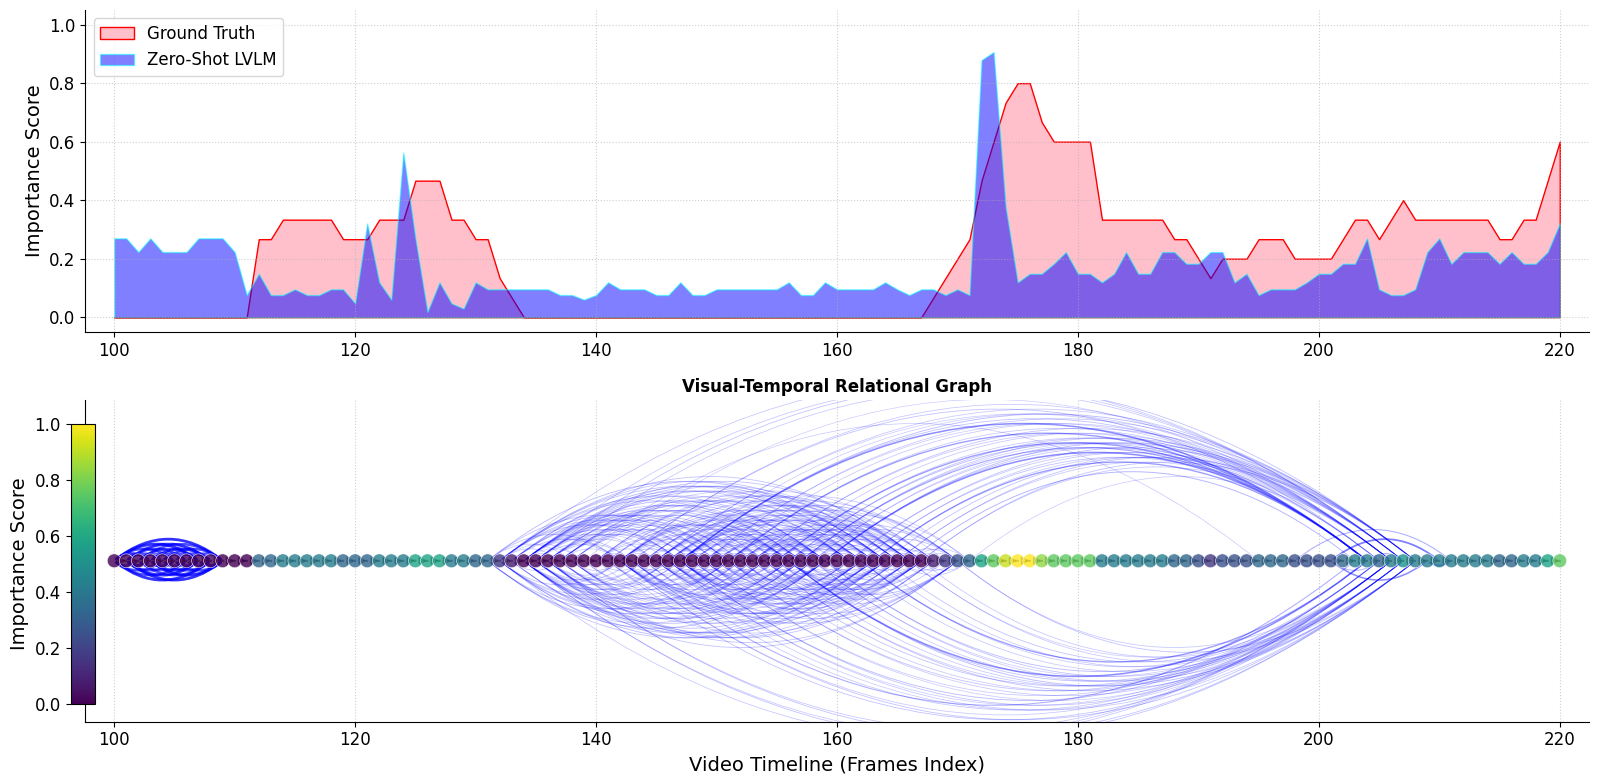

In [6]:
# ==========================================
# --- DEFINE ZOOM WINDOW ---
# Change these indices to zoom into different parts of the video
zoom_start = 100  
zoom_end = 220
padding = (zoom_end - zoom_start) * 0.02

# ==========================================
plt.rcParams.update({
    'font.size': 12,
    'axes.labelsize': 14,
    'axes.titlesize': 14,
    'legend.fontsize': 12,
    'xtick.labelsize': 12,
    'ytick.labelsize': 12,
})

# 1. Filter elements to ONLY include those inside the zoom window
sub_nodes = [i for i in range(num_nodes) if zoom_start <= i <= zoom_end]
sub_gtscore = [gtscore[i] for i in sub_nodes]

sub_backbone = [(u, v) for (u, v) in backbone_edges 
                if zoom_start <= u <= zoom_end and zoom_start <= v <= zoom_end]

# For similarity arcs, strictly require both endpoints to be inside the subview
sub_similarity = [(u, v) for (u, v) in similarity_edges 
                  if zoom_start <= u <= zoom_end and zoom_start <= v <= zoom_end]

fig, axes = plt.subplots(2,1, figsize=(16, 8), gridspec_kw={'height_ratios': [1, 1]})

# --- Timeline Subplot ---
ax_timeline = axes[0]
timeline_x = range(zoom_start, zoom_end + 1)

ax_timeline.fill_between(timeline_x, 0, gtscore[zoom_start:zoom_end + 1], 
                         color='pink', edgecolor='red', linewidth=1.0, alpha=1.0, label='Ground Truth')
ax_timeline.fill_between(timeline_x, 0, vlm_scores[zoom_start:zoom_end + 1], 
                         color='blue', edgecolor='cyan', linewidth=1.0, alpha=0.5, label='Zero-Shot LVLM')

ax_timeline.set_ylim(-0.05, 1.05)
ax_timeline.set_xlim(zoom_start - padding, zoom_end + padding) # Match limits to ax_graph

ax_timeline.set_ylabel("Importance Score")
ax_timeline.legend(loc="upper left")
ax_timeline.xaxis.set_visible(True)
ax_timeline.grid(True, linestyle=":", alpha=0.6)
ax_timeline.spines['top'].set_visible(False)
ax_timeline.spines['right'].set_visible(False)

ax_graph = axes[1]

# Position dictionary only for the nodes in our subview
pos = {i: (i, 0) for i in sub_nodes}

# A. Draw straight timeline backbone
nx.draw_networkx_edges(
    G_temporal, pos, 
    edgelist=sub_backbone, 
    ax=ax_graph, 
    edge_color="black", 
    width=1.5, 
    alpha=0.6
)

sub_weights = [G_temporal[u][v]['weight'] for (u, v) in sub_similarity]

w_min = min(sub_weights)
w_max = max(sub_weights)

# B. Draw curved long-range similarity arcs safely via Matplotlib patches
for (u, v) in sub_similarity:
    weight = G_temporal[u][v]['weight']
    norm_weight = (weight - w_min) / (w_max - w_min + 1e-8)

    x1, y1 = pos[u]
    x2, y2 = pos[v]
    # Alternate curve directions above and below the line
    rad = 0.4 if (u + v) % 2 == 0 else -0.4
        
    arc = mpatches.FancyArrowPatch(
        (x1, y1), (x2, y2),
        connectionstyle=f"arc3,rad={rad}",
        color="blue",
        alpha=0.2 + (0.6 * norm_weight),    # Stronger edges are more opaque
        linewidth=0.5 + (1.5 * norm_weight), # Stronger edges are thicker
        arrowstyle="-" 
    )
    ax_graph.add_patch(arc)

# C. Draw color-coded nodes
nodes = nx.draw_networkx_nodes(
    G_temporal, pos, 
    nodelist=sub_nodes,
    node_size=100,
    node_color=sub_gtscore, 
    cmap=plt.cm.viridis, 
    alpha=0.8, 
    ax=ax_graph,
    edgecolors='white',
    linewidths=0.5
)
cax = fig.add_axes([0.04, 0.11, 0.015, 0.35]) # [left,bottom,width,height]
sm = plt.cm.ScalarMappable(cmap=plt.cm.viridis, norm=plt.Normalize(vmin=0, vmax=1))
sm.set_array([])
fig.colorbar(sm, cax=cax, label="Importance Score", fraction=0.03, pad=0.04, location='left')

ax_graph.set_title("Visual-Temporal Relational Graph", fontsize=12, fontweight='bold')
ax_graph.set_xlabel("Video Timeline (Frames Index)")
ax_graph.get_yaxis().set_visible(False)
ax_graph.xaxis.set_visible(True)
ax_graph.tick_params(axis='x', bottom=True, labelbottom=True)
ax_graph.spines['top'].set_visible(False)
ax_graph.spines['right'].set_visible(False)

# Adjust padding based on the zoom window size
ax_graph.set_xlim(zoom_start - padding, zoom_end + padding)
ax_graph.set_ylim(-1.5, 1.5)
ax_graph.grid(True, linestyle=":", alpha=0.6)

plt.tight_layout()
plt.show()

# Graph Modelling

In [ ]:
from torch_geometric.nn import GATConv

class GAT_model(nn.Module):
    def __init__(self, in_features, hidden_dim=256, heads=4, dropout=0.3):
        super().__init__()
        self.gat1 = GATConv(in_features, hidden_dim, heads=heads, dropout=dropout)
        self.gat2 = GATConv(hidden_dim * heads, hidden_dim, heads=1, dropout=dropout)
        self.score_head = nn.Linear(hidden_dim, 1)
        self.dropout = nn.Dropout(dropout)

    def forward(self, x, edge_index):
        """
        x: Node features [num_nodes, in_features]
        edge_index: Graph connectivity [2, num_edges]
        """
        # Layer 1
        x = self.gat1(x, edge_index)
        x = F.elu(x)
        x = self.dropout(x)
        
        # Layer 2
        x = self.gat2(x, edge_index)
        x = F.elu(x)
        x = self.dropout(x)
        
        scores = self.score_head(x).squeeze(-1)
        return scores

In [ ]:
sources = [u for u, v in G_temporal.edges()]
targets = [v for u, v in G_temporal.edges()]

# Shape: [2, num_edges]
edge_index = torch.tensor([sources, targets], dtype=torch.long)

# ==========================================
# 2. PREPARE NODE FEATURES (x)
# ==========================================
# Combine base visual features with the Zero-Shot VLM scores
vlm_tensor = torch.from_numpy(vlm_scores).float().unsqueeze(-1)
x_features = torch.cat([feat_tensor, vlm_tensor], dim=-1)

in_dim = x_features.shape[-1]


model = GAT_model(in_features=in_dim, hidden_dim=64, heads=4)

# Forward pass
predicted_scores = model(x_features, edge_index)

print("--- PyG GAT Model Forward Pass Complete ---")
print(f"Input features shape: {x_features.shape}")
print(f"Edge Index shape: {edge_index.shape}")
print(f"Predicted scores shape: {predicted_scores.shape}")

In [ ]:
def mine_dpo_pairs(gtscore, vlm_scores, margin=0.3, max_pairs_per_video=1000):
    """
    Mines (chosen, rejected) node index pairs for a single video.
    """
    num_nodes = len(gtscore)
    chosen_idx = []
    rejected_idx = []
    
    # 1. Standard Margin Mining
    # Find all pairs where the difference in GT score exceeds the margin
    for i in range(num_nodes):
        for j in range(num_nodes):
            if gtscore[i] - gtscore[j] >= margin:
                chosen_idx.append(i)
                rejected_idx.append(j)
                
    # 2. Hard Negative Mining (Correcting the VLM)
    # Find nodes where GT is low but VLM score was high (VLM hallucinated importance)
    high_vlm_low_gt = np.where((vlm_scores > 0.6) & (gtscore < 0.2))[0]
    high_gt = np.where(gtscore > 0.7)[0]
    
    for u in high_gt:
        for v in high_vlm_low_gt:
            chosen_idx.append(u)
            rejected_idx.append(v)
            
    # Remove duplicates and shuffle
    pairs = list(set(zip(chosen_idx, rejected_idx)))
    random.shuffle(pairs)
    
    # Subsample to prevent massive class imbalance / memory explosion per video
    if len(pairs) > max_pairs_per_video:
        pairs = pairs[:max_pairs_per_video]
        
    if len(pairs) == 0:
        return torch.tensor([]), torch.tensor([])
        
    chosen_tensor = torch.tensor([p[0] for p in pairs], dtype=torch.long)
    rejected_tensor = torch.tensor([p[1] for p in pairs], dtype=torch.long)
    
    return chosen_tensor, rejected_tensor

In [ ]:
chosen_idx, rejected_idx = mine_dpo_pairs(gtscore, vlm_scores, margin=0.3)

In [ ]:
from torch_geometric.data import Data, Dataset
from torch_geometric.loader import DataLoader

class VideoGraphDPODataset(Dataset):
    def __init__(self, video_names, h5_data, vslice_dir, margin=0.3):
        super().__init__(root=None, transform=None, pre_transform=None)
        self.video_names = video_names
        self.h5_data = h5_data
        self.vslice_dir = vslice_dir
        self.margin = margin
        
        # In a real scenario, you would pre-process and save these Data objects 
        # to disk instead of building graphs dynamically on every __getitem__.
        self.data_list = self._process_all_videos()

    def _process_all_videos(self):
        dataset = []
        for vid in tqdm(self.video_names, desc="Creating temporal graphs from raw videos.."):
            # 1. Load Data
            features = np.array(self.h5_data[vid + '/features'])
            gtscore = np.array(self.h5_data[vid + '/gtscore'])
            picks = np.array(self.h5_data[vid + '/picks'])
            
            video_filename = str(np.array(self.h5_data[vid + '/video_name'])).strip("b'").strip('"').strip()
            vlm_data = np.load(f'{self.vslice_dir}/summe_features_{video_filename}.npz')
            vlm_scores = vlm_data['p_yes']
            
            # 2. Build Directed Graph & Edge Index
            feat_tensor = torch.from_numpy(features).float()
            picks_tensor = torch.from_numpy(picks)
            
            W_base_tensor, _ = build_adjacency_matrix_pytorch(feat_tensor, picks_tensor, window_size=200)
            W_base_np = W_base_tensor.cpu().numpy()
            
            # Use logic from earlier to create DiGraph and extract sources/targets
            num_nodes = len(picks)
            G = nx.DiGraph()
            
            for i in range(num_nodes - 1):
                G.add_edge(i, i + 1)
                
            rows, cols = np.where(W_base_np > 0)
            for r, c in zip(rows, cols):
                if r < c and abs(r - c) > 1:
                    G.add_edge(r, c)
            
            sources = [u for u, v in G.edges()]
            targets = [v for u, v in G.edges()]
            edge_index = torch.tensor([sources, targets], dtype=torch.long)
            
            # 3. Create Node Features (Visual + VLM Prior)
            vlm_tensor = torch.from_numpy(vlm_scores).float().unsqueeze(-1)
            x_features = torch.cat([feat_tensor, vlm_tensor], dim=-1)
            
            # 4. Mine DPO Pairs
            chosen_idx, rejected_idx = mine_dpo_pairs(gtscore, vlm_scores, margin=self.margin)
            
            # Skip videos where no valid pairs could be mined
            if len(chosen_idx) == 0:
                continue
            
            # 5. Pack into PyG Data Object
            data = Data(
                x=x_features, 
                edge_index=edge_index, 
                chosen_idx=chosen_idx, 
                rejected_idx=rejected_idx,
                num_nodes=num_nodes,
                gtscore=torch.from_numpy(gtscore).float(),
                video_name=vid
            )
            dataset.append(data)
            
        return dataset

    def __len__(self):
        return len(self.data_list)

    def __getitem__(self, idx):
        return self.data_list[idx]

def evaluate_graph(model, val_loader, dataset_name, h5_paths, tvsum_user_scores=None, use_advanced_scoring=False, device='cuda'):
    """
    Evaluates the trained Graph Neural Network and compares it against the base VLM scores.
    Expects a PyTorch Geometric DataLoader with batch_size=1.
    """
    h5_path = h5_paths.get(dataset_name.lower())
    model.eval()

    vlm_results = []
    graph_results = []

    with torch.no_grad():
        for batch in tqdm(val_loader, desc=f"Evaluating {dataset_name} Graph Models", leave=False):
            batch = batch.to(device)
            
            # 1. Extract video metadata
            # (Assuming you added `data.video_name = vid` during dataset creation)
            video_name = batch.video_name[0] if isinstance(batch.video_name, list) else batch.video_name
            
            # 2. Extract "Before" (Raw VLM Scores)
            # We concatenated the VLM score as the last feature in batch.x
            vlm_scores = batch.x[:, -1].cpu().float().numpy()
            
            # 3. Compute "After" (GAT Model Scores)
            logits = model(batch.x, batch.edge_index)
            # The DPO model outputs raw logits, so we apply sigmoid for evaluation [0, 1]
            graph_scores = torch.sigmoid(logits).cpu().float().numpy()
            
            # 4. Compute Metrics for VLM (Before)
            res_vlm = compute_video_metrics(
                yes_scores=vlm_scores, 
                no_scores=1 - vlm_scores, 
                h5_path=h5_path, 
                h5_key=video_name, 
                video_name=video_name,
                dataset_name=dataset_name,
                user_scores=tvsum_user_scores,
                use_advanced_scoring=use_advanced_scoring,
            )
            res_vlm['Model'] = 'Base'
            vlm_results.append(res_vlm)

            # 5. Compute Metrics for Graph Model (After Alignment)
            res_graph = compute_video_metrics(
                yes_scores=graph_scores, 
                no_scores=1 - graph_scores, 
                h5_path=h5_path, 
                h5_key=video_name, 
                video_name=video_name,
                dataset_name=dataset_name,
                user_scores=tvsum_user_scores,
                use_advanced_scoring=use_advanced_scoring,
            )
            res_graph['Model'] = 'Graph'
            graph_results.append(res_graph)

    # Combine into a single DataFrame for easy comparison
    df_vlm = pd.DataFrame(vlm_results)
    df_graph = pd.DataFrame(graph_results)
    
    return pd.concat([df_vlm, df_graph], ignore_index=True)

In [ ]:
splits = []
if args.split_file and os.path.exists(args.split_file):
    with open(args.split_file, 'r') as f:
        splits = json.load(f)
    print(f"Loaded {len(splits)} splits from {args.split_file}")

In [ ]:
dpo_dataset = VideoGraphDPODataset(splits[0]['train_keys'], h5_data, '../vslice_features/minicpm/')
dpo_loader = DataLoader(dpo_dataset, batch_size=8, shuffle=True)

graph = dpo_dataset.__getitem__(1)
in_dim = graph.x.shape[1]  # Should be 1025 based on your previous print
print(in_dim)
model = GAT_model(in_features=in_dim, hidden_dim=64, heads=4)

predicted_scores = model(graph.x, graph.edge_index)
print(predicted_scores.shape)

In [ ]:
# Initialize Models
# model_policy is the one we train. model_ref is the frozen baseline.
model_policy = GAT_model(in_features=in_dim, hidden_dim=128, heads=4).cuda()
model_ref = copy.deepcopy(model_policy).cuda()
model_ref.eval() # Freeze reference model

optimizer = torch.optim.AdamW(model_policy.parameters(), lr=1e-5)
beta = 0.5 # DPO temperature scaling

def train_sft_phase(model, dataloader, epochs=50, lr=3e-4, device='cuda'):
    """Phase 1: Supervised Fine-Tuning using Ground Truth Scores"""
    print("--- Starting Phase 1: Supervised Pre-training (SFT) ---")
    optimizer = torch.optim.AdamW(model.parameters(), lr=lr)
    criterion = nn.MSELoss()
    
    model.train()
    for epoch in range(epochs):
        total_loss = 0
        for batch in dataloader:
            batch = batch.to(device)
            optimizer.zero_grad()
            
            logits = model(batch.x, batch.edge_index)
            preds = torch.sigmoid(logits)
            loss = criterion(preds, batch.gtscore) 
            
            loss.backward()
            optimizer.step()
            total_loss += loss.item()
            
        if (epoch + 1) % 10 == 0:
            print(f"SFT Epoch {epoch+1}/{epochs} | MSE Loss: {total_loss / len(dataloader):.4f}")
            
    return model

def train_dpo_phase(model_policy, model_ref, dataloader, epochs=20, lr=1e-5, beta=0.1, device='cuda'):
    """Phase 2: Direct Preference Optimization using Mined Pairs"""
    print("\n--- Starting Phase 2: DPO Alignment ---")
    model_ref.eval() # Reference model must be strictly frozen
    optimizer = torch.optim.AdamW(model_policy.parameters(), lr=lr)
    
    model_policy.train()
    for epoch in range(epochs):
        total_loss = 0
        for batch in dataloader:
            batch = batch.to(device)
            optimizer.zero_grad()
            
            # Forward pass through both models
            scores_policy = model_policy(batch.x, batch.edge_index)
            with torch.no_grad():
                scores_ref = model_ref(batch.x, batch.edge_index)
                
            # Extract Chosen vs Rejected
            policy_chosen = scores_policy[batch.chosen_idx]
            policy_rejected = scores_policy[batch.rejected_idx]
            
            ref_chosen = scores_ref[batch.chosen_idx]
            ref_rejected = scores_ref[batch.rejected_idx]
            
            pi_logratios = policy_chosen - policy_rejected
            ref_logratios = ref_chosen - ref_rejected
            
            # Bradley-Terry DPO Loss
            logits = pi_logratios - ref_logratios
            loss = -F.logsigmoid(beta * logits).mean()
            
            loss.backward()
            optimizer.step()
            total_loss += loss.item()
            
        if (epoch + 1) % 10 == 0:
            print(f"DPO Epoch {epoch+1}/{epochs} | DPO Loss: {total_loss / len(dataloader):.4f}")
            
    return model_policy

# ==========================================
# 3. EXECUTION SCRIPT
# (SCORES) SUMME:0.264 0.294 TVSUM: 0.236 0.305
# ==========================================

h5_paths = {
        "summe": os.path.join(args.root_dir, "SumMe", "eccv16_dataset_summe_google_pool5.h5"),
        "tvsum": os.path.join(args.root_dir, "TVSum", "eccv16_dataset_tvsum_google_pool5.h5")
}

in_dim = 1025

base_eval_split_metrics = {}
graph_eval_split_metrics = {}

if __name__ == "__main__":
    device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
    
    for split_idx, split in enumerate(splits):
        print(f"\n==================== SPLIT {split_idx+1}/{len(splits)} ====================")
        
        train_videos, test_videos = split['train_keys'], split['test_keys']
        
        train_dataset = VideoGraphDPODataset(train_videos, h5_data, '../vslice_features/minicpm/')
        train_loader = DataLoader(train_dataset, batch_size=16, shuffle=True)
        
        val_dataset = VideoGraphDPODataset(test_videos, h5_data, '../vslice_features/minicpm/')
        val_loader = DataLoader(val_dataset, batch_size=1, shuffle=False)
        
        base_model = GAT_model(in_features=in_dim, hidden_dim=64, heads=4).to(device)
        sft_model = train_sft_phase(base_model, dpo_loader, epochs=50, lr=3e-4, device=device)
        
        model_policy = copy.deepcopy(sft_model).to(device)
        model_ref = copy.deepcopy(sft_model).to(device)
        
        final_aligned_model = train_dpo_phase(
            model_policy=model_policy, 
            model_ref=model_ref, 
            dataloader=dpo_loader, 
            epochs=50,
            lr=1e-3, 
            beta=0.1, 
            device=device
        )
        
        print(f"\nTraining SPLIT {split_idx+1}/{len(splits)} Complete! `final_aligned_model` is ready for inference.")

        df_final = evaluate_graph(
            model=final_aligned_model, 
            val_loader=val_loader, 
            dataset_name=dataset_name, 
            h5_paths=h5_paths,
            device=device
        )

        print("\n--- Evaluation Results ---")
        print("Zero-Shot VLM - Kendall Tau:{:.4f} | Spearman Rho:{:.4f}".format(
            df_final[df_final["Model"] == "Base"]["kendall"].mean(), 
            df_final[df_final["Model"] == "Base"]["spearman"].mean()
            ))
            
        print("GAT Aligned - Kendall Tau:{:.4f} | Spearman Rho:{:.4f}".format(
            df_final[df_final["Model"] == "Graph"]["kendall"].mean(), 
            df_final[df_final["Model"] == "Graph"]["spearman"].mean()
            ))

        base_eval_split_metrics[split_idx] = {}
        base_eval_split_metrics[split_idx]['f_score'] = df_final[df_final["Model"] == "Base"]["f_score"].mean()
        base_eval_split_metrics[split_idx]['kendall'] = df_final[df_final["Model"] == "Base"]["kendall"].mean()
        base_eval_split_metrics[split_idx]['spearman'] = df_final[df_final["Model"] == "Base"]["spearman"].mean()

        graph_eval_split_metrics[split_idx] = {}
        graph_eval_split_metrics[split_idx]['f_score'] = df_final[df_final["Model"] == "Graph"]["f_score"].mean()
        graph_eval_split_metrics[split_idx]['kendall'] = df_final[df_final["Model"] == "Graph"]["kendall"].mean()
        graph_eval_split_metrics[split_idx]['spearman'] = df_final[df_final["Model"] == "Graph"]["spearman"].mean()

    print("\n" + "═"*60)
    print(f"FINAL GLOBAL BENCHMARK SUMMARY ({len(splits)} SPLITS)")
    print("═"*60)
        
    avg_base_f1 = np.mean([m['f_score'] for m in base_eval_split_metrics.values()])
    avg_base_tau = np.mean([m['kendall'] for m in base_eval_split_metrics.values()])
    avg_base_rho = np.mean([m['spearman'] for m in base_eval_split_metrics.values()])
        
    avg_graph_f1 = np.mean([m['f_score'] for m in graph_eval_split_metrics.values()])
    avg_graph_tau = np.mean([m['kendall'] for m in graph_eval_split_metrics.values()])
    avg_graph_rho = np.mean([m['spearman'] for m in graph_eval_split_metrics.values()])
        
    print("Zero-Shot VLM (Base) Global Avg:")
    print(f"F1: {avg_base_f1:.4f} | Kendall: {avg_base_tau:.4f} | Spearman: {avg_base_rho:.4f}\n")
        
    print("GAT Aligned (Graph) Global Avg:")
    print(f"F1: {avg_graph_f1:.4f} | Kendall: {avg_graph_tau:.4f} | Spearman: {avg_graph_rho:.4f}")
    print("═"*60)

In [ ]:
from torch.utils.data import DataLoader
from vslice_utils.llava_summe_video_dataset import SumMeLLaMA_VideoDataset, SumMeLLaMA_DPODataset, DPOTrainBatchCollator, ValBatchCollator
from vslice_utils.llava_tvsum_video_dataset import TVSumLLaMA_VideoDataset, TVSumLLaMA_DPODataset, DPOTrainBatchCollator, ValBatchCollator
from vslice_utils.dataloader import build_summe_manifest, build_tvsum_manifest, VideoSegmentDataset

def evaluate(model, val_loader, dataset_name, h5_paths, tvsum_user_scores=None, use_advanced_scoring=False, yes_id=9454, no_id=2753):
    """
    Evaluates the model using the ValBatchCollator and val_loader.
    """
    split_results = []
    h5_path = h5_paths.get(dataset_name.lower())
    model.eval()

    # --- DIAGNOSTIC ACCUMULATORS ---
    all_preds = []

    with torch.no_grad():
        for step, batch_data in enumerate(tqdm(val_loader, desc=f"Evaluating {dataset_name}", leave=False)):
            
            video_name = batch_data.pop("video_name")[0]
            titles = batch_data.pop("title")
            gtscores = batch_data.pop("gtscore")
            features = batch_data.pop("features")
            
            n_frames = batch_data.pop("n_frames")[0]
            n_frame_per_seg = batch_data.pop("n_frame_per_seg")[0]
            picks = batch_data.pop("picks")[0]
            change_points = batch_data.pop("change_points")[0]
            gt_summary = batch_data.pop("gt_summary")[0]

            batch_data = batch_data.to(device)

            chunk_size = 8
            num_frames = batch_data["input_ids"].size(0)
            all_preds_chunk = []
            
            for start_idx in range(0, num_frames, chunk_size):
                end_idx = min(start_idx + chunk_size, num_frames)
                
                # Create a mini-batch by slicing elements
                mini_batch_dict = {}
                for k, v in batch_data.items():
                    if isinstance(v, torch.Tensor) and v.size(0) == num_frames:
                        mini_batch_dict[k] = v[start_idx:end_idx]
                    elif isinstance(v, list) and len(v) == num_frames:
                        mini_batch_dict[k] = v[start_idx:end_idx]
                    else:
                        mini_batch_dict[k] = v
                        
                mini_batch = type(batch_data)(mini_batch_dict)
                
                chunk_outputs = model.base_model(mini_batch)
                chunk_logits = chunk_outputs.logits[:, -1, :]
                chunk_binary_probs = F.softmax(
                    torch.stack([chunk_logits[:, yes_id], chunk_logits[:, no_id]], dim=-1), dim=-1
                )
                all_preds_chunk.append(chunk_binary_probs[:, 0].detach().cpu().float())
                
                del chunk_outputs, chunk_logits, mini_batch, mini_batch_dict
                torch.cuda.empty_cache()
                
            preds = torch.cat(all_preds_chunk, dim=0)
            
            yes_scores = preds.numpy()
            all_preds.extend(yes_scores)

            res = compute_video_metrics(
                yes_scores=yes_scores, 
                no_scores=1-yes_scores, 
                h5_path=h5_path, 
                h5_key=video_name, 
                video_name=video_name,
                dataset_name=dataset_name,
                user_scores=tvsum_user_scores,
                use_advanced_scoring=use_advanced_scoring,
            )

            split_results.append(res)

    all_preds = np.array(all_preds)
    unique_preds = len(np.unique(all_preds))
    return pd.DataFrame(split_results)
